In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df = pd.read_csv('data/AirQuality.csv',sep=';',decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [21]:
print(df.shape)
print(df.info())

(9471, 17)
<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB
None


In [22]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


In [23]:
df.replace(-200, np.nan , inplace=True)

df.drop(columns=['Unnamed: 15','Unnamed: 16'],inplace=True , errors='ignore')

df.dropna(subset=['CO(GT)'],inplace=True)

df.fillna(df.mean(numeric_only=True),inplace=True)

print(df.shape)

(7674, 15)


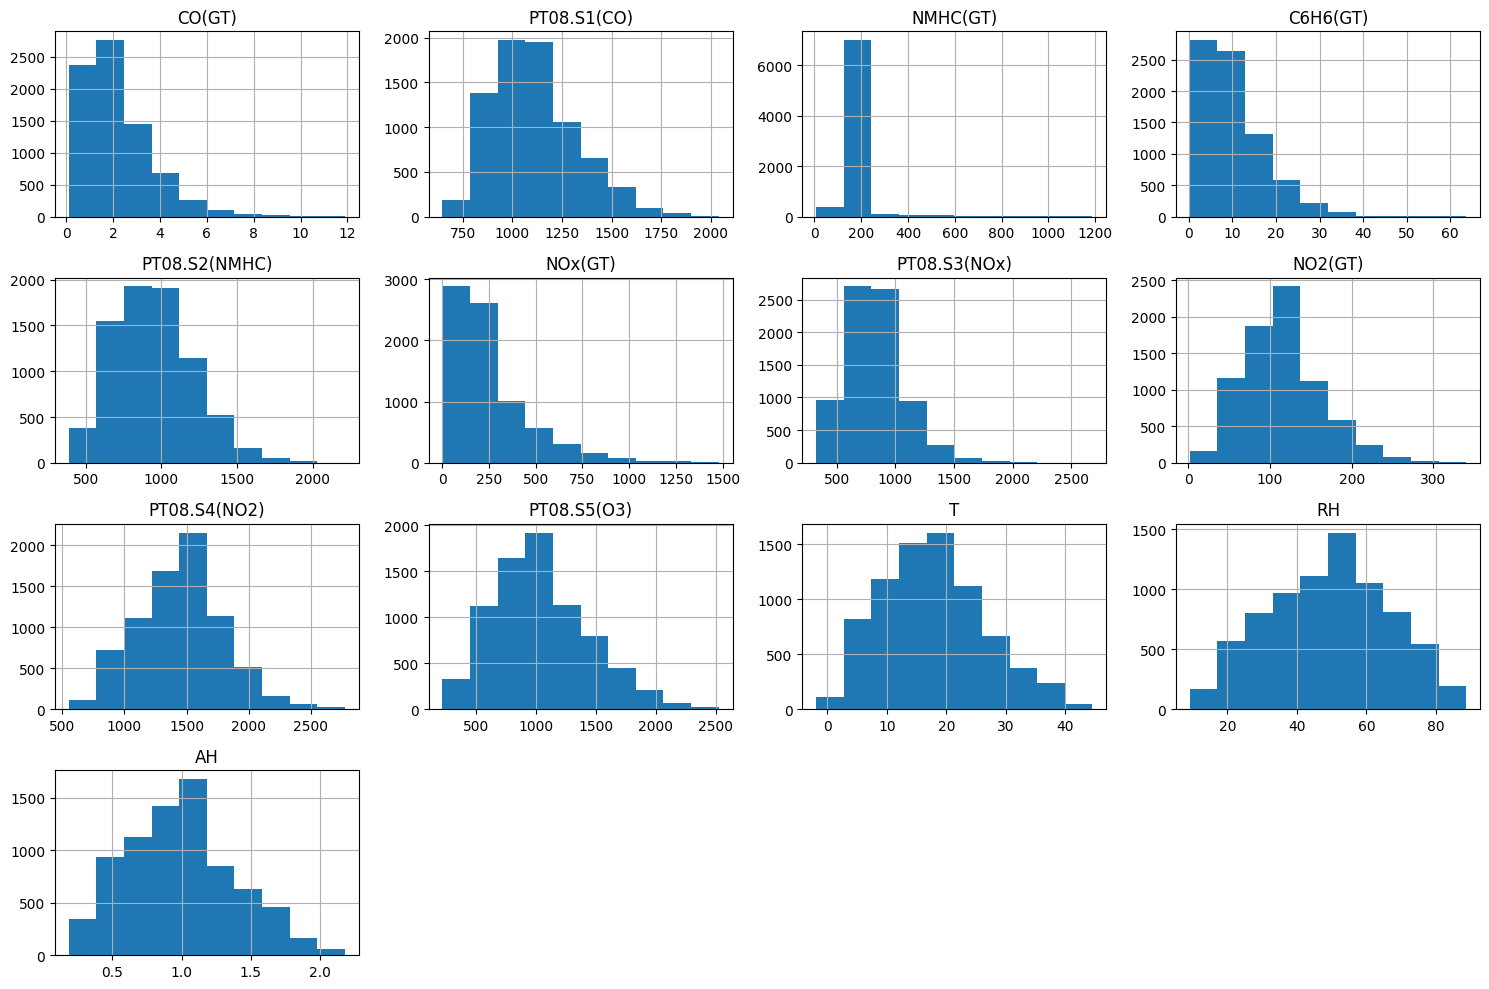

In [24]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

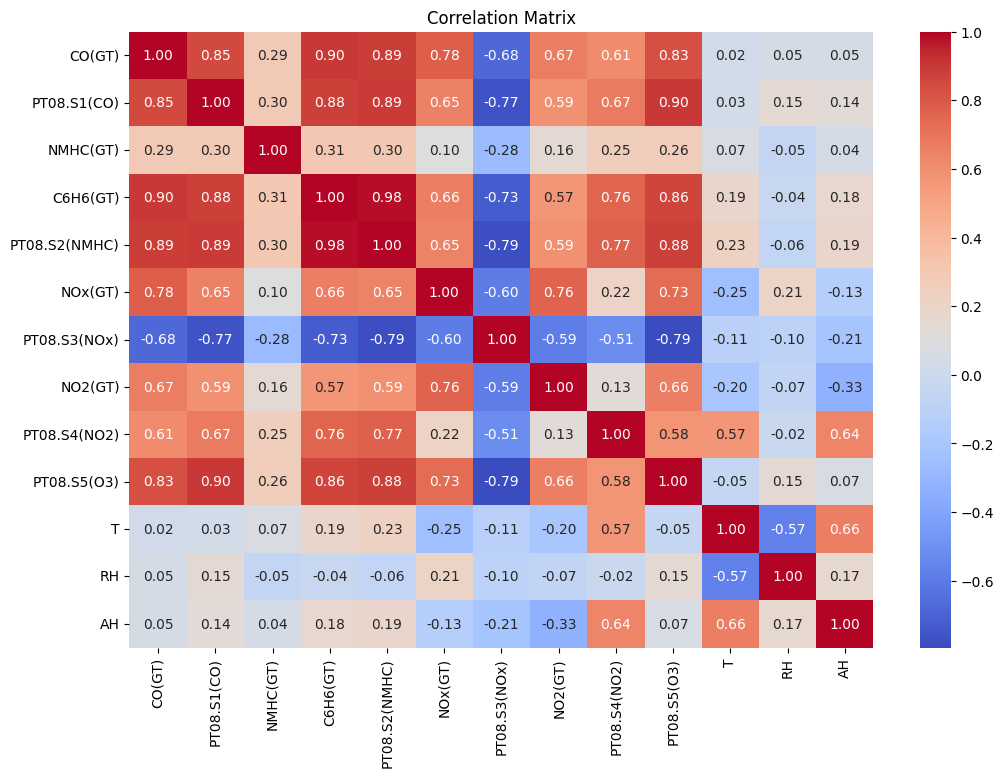

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

In [26]:
y = df['CO(GT)']

X = df.drop(columns=['CO(GT)', 'Date', 'Time'])

print(X.shape)
print(y.shape)

(7674, 12)
(7674,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f'Train set : {X_train.shape}')
print(f'Test Set: {X_test.shape}')

Train set : (6139, 12)
Test Set: (1535, 12)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print('Normalization completed')



Normalization completed


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 

lr_model =LinearRegression()

lr_model.fit(X_train_scaled , y_train)

y_pred = lr_model.predict(X_test_scaled)

mse =mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

MSE: 0.227
RMSE: 0.477
R²: 0.891


In [30]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=10,random_state=42)

dt_model.fit(X_train_scaled,y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

mse_dt =mean_squared_error(y_test,y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test,y_pred_dt)

print(f' DT MSE: {mse_dt:.3f}')
print(f'DT RMSE: {rmse_dt:.3f}')
print(f' DT R²: {r2_dt:.3f}')

 DT MSE: 0.233
DT RMSE: 0.483
 DT R²: 0.888


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model =RandomForestRegressor(n_estimators=100,random_state=42)

rf_model.fit(X_train_scaled,y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)

print(f'RF MSE: {mse_rf:.3f}')
print(f'RF RMSE: {rmse_rf:.3f}')
print(f'RF R²: {r2_rf:.3f}')

RF MSE: 0.152
RF RMSE: 0.389
RF R²: 0.927


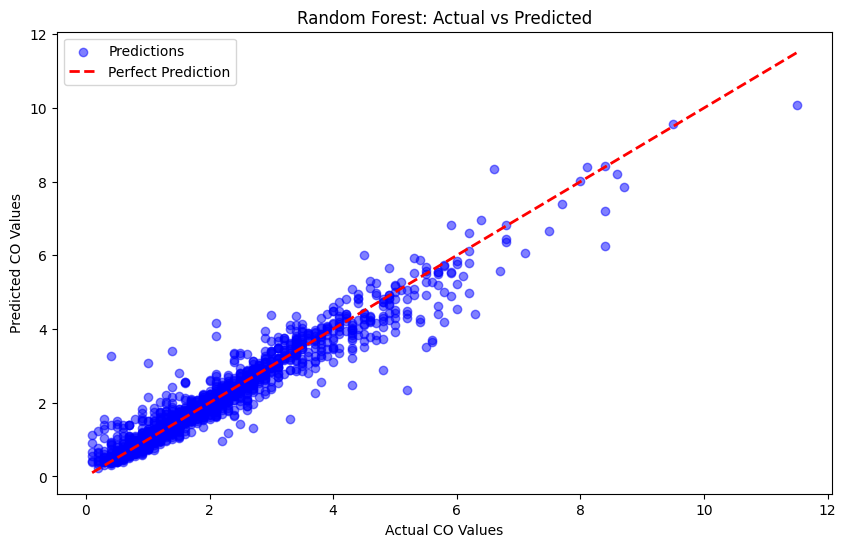

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(y_test,y_pred_rf,alpha=0.5,color='blue',label='Predictions')

plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual CO Values')
plt.ylabel('Predicted CO Values')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.show()



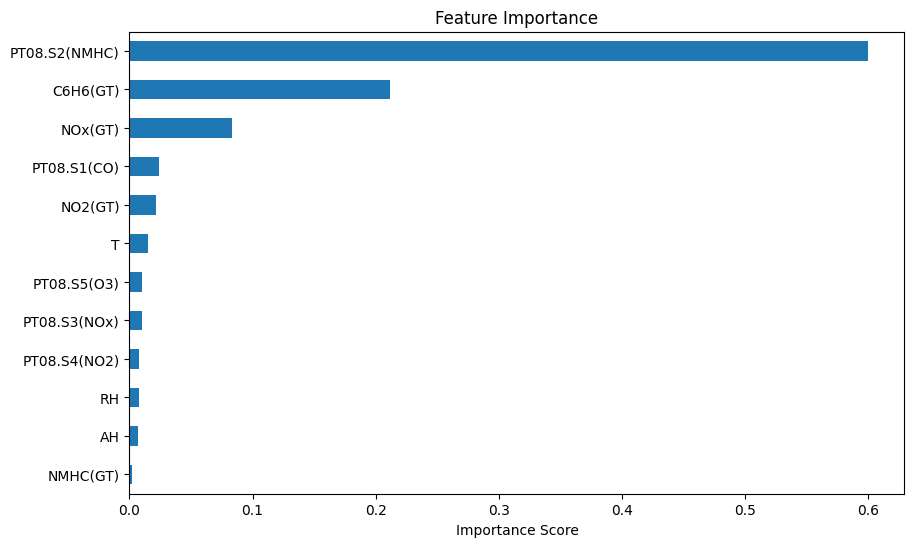

In [33]:
feature_importance =pd.Series(rf_model.feature_importances_ , index = X.columns)

feature_importance.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()



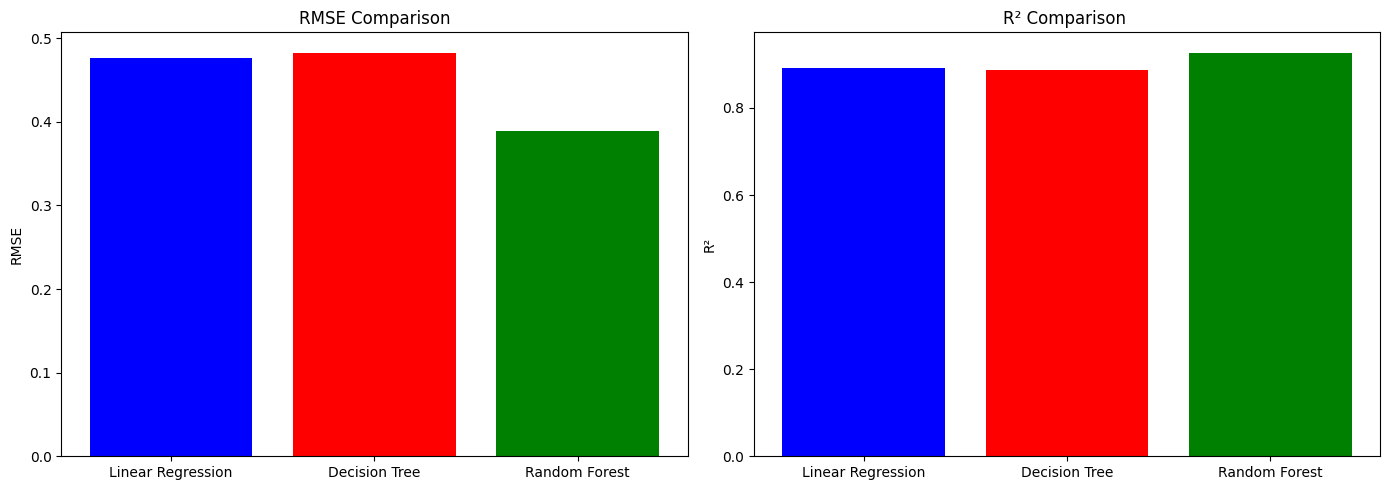

In [34]:
models = ['Linear Regression','Decision Tree','Random Forest']

rmse_scores = [rmse,rmse_dt,rmse_rf]
r2_scores = [r2,r2_dt,r2_rf]

fig,axes = plt.subplots(1,2,figsize=(14,5))

axes[0].bar(models, rmse_scores, color=['blue', 'red', 'green'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')

axes[1].bar(models, r2_scores, color=['blue', 'red', 'green'])
axes[1].set_title('R² Comparison ')
axes[1].set_ylabel('R²')


plt.tight_layout()
plt.show()